In [68]:
import control as ct
import math
import matplotlib.pyplot as plt

In [69]:
s =ct.tf('s')

In [70]:
L=(2.5+2.66)*1E-3
R=2*0.01
Tf=L/R
Fs=10E3
Ts=1/Fs
Wn=2*math.pi*Fs/10
print('L=',L,'R=',R)
print('Ts=',Ts)
print('Wn=',Wn)

L= 0.0051600000000000005 R= 0.02
Ts= 0.0001
Wn= 6283.185307179587


In [71]:
G1=1/(L*s+R)
print(G1)

<TransferFunction>: sys[109]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         1
  ----------------
  0.00516 s + 0.02


In [72]:
plant=G1
print(plant)

<TransferFunction>: sys[109]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         1
  ----------------
  0.00516 s + 0.02


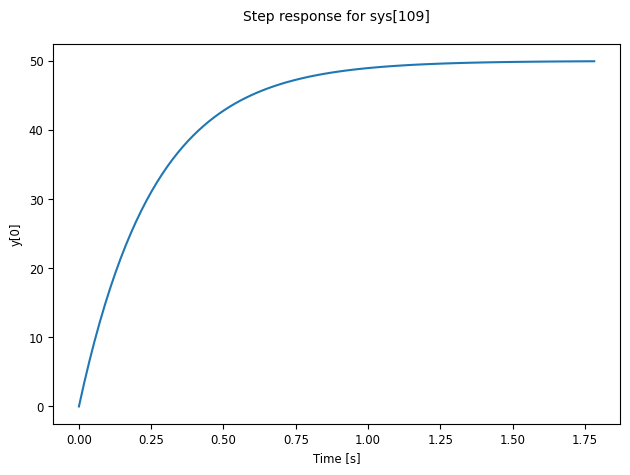

In [73]:
response = ct.step_response(plant)
cplt = response.plot()

In [53]:
Kp=2*1.1*Wn*L-R
print('Kp=',Kp)

Kp= 71.30671960710268


In [54]:
Ki=Wn*Wn*L
print('Ki=',Ki)

Ki= 203708.6348384844


In [55]:
controller=Kp+Ki/s
print('controller',controller)

controller <TransferFunction>: sys[83]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  71.31 s + 2.037e+05
  -------------------
           s


In [56]:
Gopen=controller*plant
print(Gopen)

<TransferFunction>: sys[84]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  71.31 s + 2.037e+05
  --------------------
  0.00516 s^2 + 0.02 s


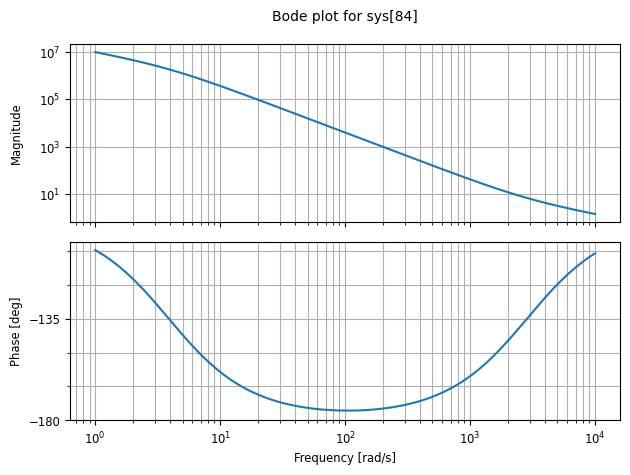

In [57]:
freqresp = ct.frequency_response(Gopen)
cplt = freqresp.plot()

In [78]:
G=Gopen/(1+Gopen)
print(G)

<TransferFunction>: sys[122]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          0.3679 s^3 + 1053 s^2 + 4074 s
  ----------------------------------------------
  2.663e-05 s^4 + 0.3681 s^3 + 1053 s^2 + 4074 s


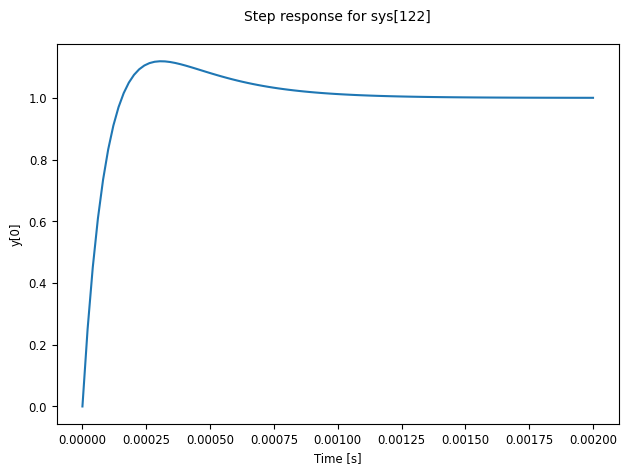

In [84]:
response = ct.step_response(G, T=2E-3)
cplt = response.plot()


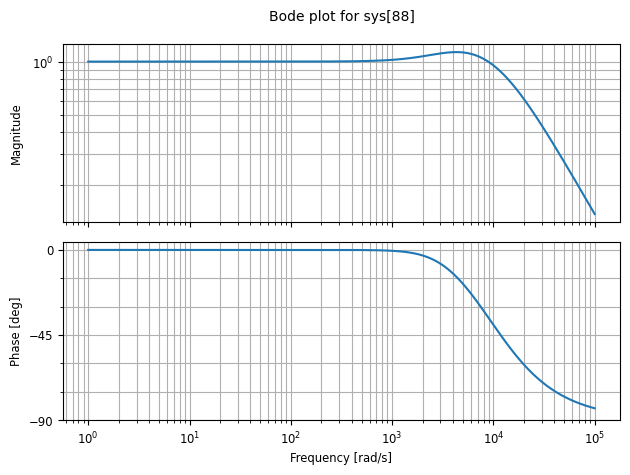

In [60]:
freqresp = ct.frequency_response(G)
cplt = freqresp.plot()